# 🤖 Agentic AI Notes Generator

An AI-powered notes generation system built with:

- **Groq** — fast LLM inference
- **LangChain** — prompts, models, document processing
- **LangGraph** — agent workflow and state management
- **Hugging Face** *(optional)* — embeddings / local NLP models
- **MongoDB** — persistent notes, documents, conversations and user data
- **Memory** — conversation-aware note refinement

## Features

- Generate structured study notes from a topic or source text
- Create summaries, key concepts, examples and important points
- Automatically validate note quality
- Improve weak notes through a refinement loop
- Remember previous conversation context
- Save generated notes and chat history in MongoDB
- Support follow-up requests such as:
  - "Make these notes shorter"
  - "Add examples"
  - "Explain this for beginners"
  - "Create interview questions from these notes"

## Agent Workflow

User Request
      ↓
Input Analyzer
      ↓
Research / Context Agent
      ↓
Notes Generator
      ↓
Quality Validator
      ↓
   Valid?
   ↙    ↘
 No      Yes
 ↓        ↓
Refiner   Save to MongoDB
 ↓        ↓
Validator Final Response


In [1]:
# Install required packages

! pip install -qU langchain langchain-groq langgraph langchain-community
! pip install -qU pymongo motor python-dotenv pydantic
! pip install -qU langchain-huggingface sentence-transformers

# Optional:
# !pip install -qU tavily-python


## 1. Environment Variables

Create a `.env` file with:

```env
GROQ_API_KEY=your_groq_api_key
MONGODB_URI=your_mongodb_connection_string
```

Hugging Face is optional. You only need a Hugging Face token for models/services that require authentication.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
MONGODB_URI = os.getenv("MONGODB_URI")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is missing")

if not MONGODB_URI:
    raise ValueError("MONGODB_URI is missing")

print("Environment variables loaded successfully.")


Environment variables loaded successfully.


## 2. Imports


In [4]:
from typing import TypedDict, Annotated, Optional, Literal
from datetime import datetime
from uuid import uuid4

from pydantic import BaseModel, Field

from pymongo import MongoClient

from langchain_groq import ChatGroq
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    SystemMessage,
    BaseMessage,
)
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


## 3. Initialize MongoDB

MongoDB stores:

- Users
- Generated notes
- Source documents
- Conversation history
- Agent metadata

### Suggested Collections

```text
ai_notes_db
│
├── users
├── notes
├── conversations
└── documents
```


In [5]:
mongo_client = MongoClient(MONGODB_URI)

db = mongo_client["ai_notes_db"]

users_collection = db["users"]
notes_collection = db["notes"]
conversations_collection = db["conversations"]
documents_collection = db["documents"]

print("MongoDB connected successfully.")


MongoDB connected successfully.


## 4. Initialize Groq LLM

You can change the model depending on availability in your Groq account.


In [7]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0.3,
    api_key=GROQ_API_KEY,
)

print("Groq LLM initialized.")


Groq LLM initialized.


## 5. Optional Hugging Face Embeddings

Embeddings are useful when you later add:

- PDF/document retrieval
- Semantic search
- Similar notes search
- RAG
- Context retrieval

The Notes Generator itself does **not** need embeddings for simple topic-based generation.


In [8]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

print("Hugging Face embeddings initialized.")


c:\Users\sk335\OneDrive\Documents\Coding\PythonProjects\ai-lab-projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6421.03it/s]


Hugging Face embeddings initialized.


## 6. Define Structured Note Output

Using structured data makes the application easier to integrate with a React frontend later.


In [9]:
class StudyNote(BaseModel):
    title: str = Field(description="Clear title for the notes")
    summary: str = Field(description="Short summary of the topic")
    key_concepts: list[str] = Field(description="Important concepts")
    detailed_notes: list[str] = Field(description="Detailed explanations")
    examples: list[str] = Field(description="Practical examples")
    important_points: list[str] = Field(description="Important points to remember")
    beginner_friendly: bool = Field(
        description="Whether the explanation is beginner friendly"
    )


class ValidationResult(BaseModel):
    is_valid: bool
    score: int = Field(ge=1, le=10)
    issues: list[str]
    suggestions: list[str]


## 7. Define LangGraph State

This state is shared between all agents.


In [10]:
class NotesAgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

    user_id: str
    conversation_id: str

    user_query: str
    topic: str

    source_context: str

    note_style: str
    difficulty_level: str

    generated_notes: Optional[dict]

    validation_result: Optional[dict]

    refinement_count: int

    final_response: str

    metadata: dict


## 8. Memory Functions

We use MongoDB as persistent conversation memory.

This allows the agent to understand follow-up requests.

Example:

```text
User: Create notes about JavaScript closures

Later...

User: Make them shorter and add examples

The agent can retrieve the previous context.
```


In [11]:
def get_conversation_memory(conversation_id: str, limit: int = 10):
    conversation = conversations_collection.find_one(
        {"conversation_id": conversation_id}
    )

    if not conversation:
        return []

    messages = conversation.get("messages", [])

    return messages[-limit:]


def save_conversation_message(
    conversation_id: str,
    user_id: str,
    role: str,
    content: str,
):
    conversations_collection.update_one(
        {
            "conversation_id": conversation_id,
            "user_id": user_id,
        },
        {
            "$push": {
                "messages": {
                    "role": role,
                    "content": content,
                    "created_at": datetime.utcnow(),
                }
            },
            "$set": {
                "updated_at": datetime.utcnow()
            },
            "$setOnInsert": {
                "created_at": datetime.utcnow()
            },
        },
        upsert=True,
    )


## 9. Load Previous Memory into LangChain Messages


In [12]:
def load_memory_messages(conversation_id: str):
    memory = get_conversation_memory(conversation_id)

    messages = []

    for item in memory:
        if item["role"] == "user":
            messages.append(HumanMessage(content=item["content"]))
        else:
            messages.append(AIMessage(content=item["content"]))

    return messages


# 🤖 AGENTS

The system uses multiple specialized nodes.

1. **Input Analyzer** → understands the request
2. **Context Agent** → prepares context
3. **Notes Generator** → creates notes
4. **Validator Agent** → checks quality
5. **Refiner Agent** → improves notes
6. **MongoDB Storage Agent** → saves results
7. **Final Response Agent** → prepares output


## 10. Input Analyzer Agent

This agent determines whether the user wants:

- New notes
- Shorter notes
- More examples
- Beginner-friendly explanation
- Interview preparation notes
- Revision of existing notes


In [13]:
analyzer_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are an input analysis agent for an AI Notes Generator.

Analyze the user's request.

Extract:
- main topic
- requested note style
- difficulty level
- whether previous conversation context is relevant

Return a concise analysis.
""",
    ),
    ("human", "{query}"),
])


def input_analyzer_node(state: NotesAgentState):
    response = llm.invoke(
        analyzer_prompt.format_messages(
            query=state["user_query"]
        )
    )

    return {
        "messages": [AIMessage(content=response.content)],
        "topic": state["user_query"],
    }


## 11. Context Agent

This prepares the context used by the Notes Generator.

Later, you can extend this node with:

- PDF RAG
- Web search
- MongoDB semantic search
- Vector database retrieval


In [14]:
def context_agent_node(state: NotesAgentState):
    memory_messages = load_memory_messages(
        state["conversation_id"]
    )

    previous_context = "\n".join(
        [
            f"{message.type}: {message.content}"
            for message in memory_messages[-6:]
        ]
    )

    context = f"""
Previous conversation context:

{previous_context}

Current user request:

{state["user_query"]}
"""

    return {
        "source_context": context
    }


## 12. Notes Generator Agent

This is the main generation agent.

It uses Groq and structured output.


In [15]:
notes_generator_llm = llm.with_structured_output(StudyNote)

notes_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are an expert AI Study Notes Generator.

Create high-quality educational notes.

Requirements:

- Use clear headings and structure
- Explain concepts accurately
- Match the requested difficulty level
- Include practical examples
- Avoid unnecessary repetition
- Make the notes useful for revision

Difficulty level: {difficulty_level}

Note style: {note_style}
""",
    ),
    (
        "human",
        """
User request:

{query}

Available context:

{context}
""",
    ),
])


def notes_generator_node(state: NotesAgentState):
    notes = notes_generator_llm.invoke(
        notes_prompt.format_messages(
            query=state["user_query"],
            context=state["source_context"],
            difficulty_level=state["difficulty_level"],
            note_style=state["note_style"],
        )
    )

    return {
        "generated_notes": notes.model_dump(),
        "messages": [
            AIMessage(
                content=f"Generated notes for: {notes.title}"
            )
        ],
    }


## 13. Notes Quality Validator Agent

The validator checks:

- Accuracy
- Completeness
- Clarity
- Examples
- Structure
- Repetition


In [16]:
validator_llm = llm.with_structured_output(ValidationResult)

validator_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are a strict educational content validator.

Evaluate the generated study notes.

Check:

1. Clarity
2. Completeness
3. Logical structure
4. Usefulness for learning
5. Quality of examples
6. Unnecessary repetition

Return a score from 1 to 10.

Notes with a score of 7 or higher should normally be considered valid.
""",
    ),
    (
        "human",
        "Generated notes:\n{notes}"
    ),
])


def validator_node(state: NotesAgentState):
    result = validator_llm.invoke(
        validator_prompt.format_messages(
            notes=str(state["generated_notes"])
        )
    )

    return {
        "validation_result": result.model_dump(),
        "messages": [
            AIMessage(
                content=f"Validation score: {result.score}/10"
            )
        ],
    }


## 14. Conditional Routing

If the notes are weak, LangGraph routes them to the Refiner Agent.

Otherwise, the workflow saves them to MongoDB.


In [17]:
def should_refine(state: NotesAgentState) -> Literal["refine", "save"]:
    validation = state["validation_result"]

    score = validation.get("score", 0)
    is_valid = validation.get("is_valid", False)

    refinement_count = state.get("refinement_count", 0)

    if (
        (not is_valid or score < 7)
        and refinement_count < 2
    ):
        return "refine"

    return "save"


## 15. Notes Refiner Agent

This agent improves notes based on validator feedback.


In [18]:
refiner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are a Notes Improvement Agent.

Improve the study notes based on validator feedback.

Fix:

- Missing information
- Weak explanations
- Poor examples
- Repetition
- Structural problems

Return improved structured study notes.
""",
    ),
    (
        "human",
        """
Current notes:

{notes}

Validator feedback:

Issues:
{issues}

Suggestions:
{suggestions}
""",
    ),
])

refiner_llm = llm.with_structured_output(StudyNote)


def refiner_node(state: NotesAgentState):
    validation = state["validation_result"]

    improved_notes = refiner_llm.invoke(
        refiner_prompt.format_messages(
            notes=str(state["generated_notes"]),
            issues=validation["issues"],
            suggestions=validation["suggestions"],
        )
    )

    return {
        "generated_notes": improved_notes.model_dump(),
        "refinement_count": state.get(
            "refinement_count", 0
        ) + 1,
        "messages": [
            AIMessage(
                content="Notes were improved based on validation feedback."
            )
        ],
    }


## 16. MongoDB Storage Agent

Save the final generated notes.


In [19]:
def save_notes_node(state: NotesAgentState):
    note_id = str(uuid4())

    note_document = {
        "note_id": note_id,
        "user_id": state["user_id"],
        "conversation_id": state["conversation_id"],
        "topic": state["topic"],
        "notes": state["generated_notes"],
        "note_style": state["note_style"],
        "difficulty_level": state["difficulty_level"],
        "validation": state["validation_result"],
        "created_at": datetime.utcnow(),
        "metadata": state["metadata"],
    }

    notes_collection.insert_one(note_document)

    return {
        "metadata": {
            **state["metadata"],
            "note_id": note_id,
        }
    }


## 17. Final Response Agent


In [20]:
def final_response_node(state: NotesAgentState):
    notes = state["generated_notes"]
    note_id = state["metadata"].get("note_id")

    response = f"""
# {notes["title"]}

## Summary
{notes["summary"]}

## Key Concepts

""" + "\n".join(
        f"- {item}" for item in notes["key_concepts"]
    ) + """

## Detailed Notes

""" + "\n".join(
        f"- {item}" for item in notes["detailed_notes"]
    ) + """

## Examples

""" + "\n".join(
        f"- {item}" for item in notes["examples"]
    ) + """

## Important Points

""" + "\n".join(
        f"- {item}" for item in notes["important_points"]
    ) + f"""

---
Note ID: {note_id}
"""

    save_conversation_message(
        conversation_id=state["conversation_id"],
        user_id=state["user_id"],
        role="assistant",
        content=response,
    )

    return {
        "final_response": response,
        "messages": [
            AIMessage(content=response)
        ],
    }


# 🕸️ Build the LangGraph Workflow


In [21]:
workflow = StateGraph(NotesAgentState)

workflow.add_node(
    "input_analyzer",
    input_analyzer_node,
)

workflow.add_node(
    "context_agent",
    context_agent_node,
)

workflow.add_node(
    "notes_generator",
    notes_generator_node,
)

workflow.add_node(
    "validator",
    validator_node,
)

workflow.add_node(
    "refiner",
    refiner_node,
)

workflow.add_node(
    "save_notes",
    save_notes_node,
)

workflow.add_node(
    "final_response",
    final_response_node,
)


workflow.add_edge(
    START,
    "input_analyzer",
)

workflow.add_edge(
    "input_analyzer",
    "context_agent",
)

workflow.add_edge(
    "context_agent",
    "notes_generator",
)

workflow.add_edge(
    "notes_generator",
    "validator",
)

workflow.add_conditional_edges(
    "validator",
    should_refine,
    {
        "refine": "refiner",
        "save": "save_notes",
    },
)

workflow.add_edge(
    "refiner",
    "validator",
)

workflow.add_edge(
    "save_notes",
    "final_response",
)

workflow.add_edge(
    "final_response",
    END,
)


app = workflow.compile()

print("LangGraph workflow compiled successfully.")


LangGraph workflow compiled successfully.


## 18. Visualize the Graph


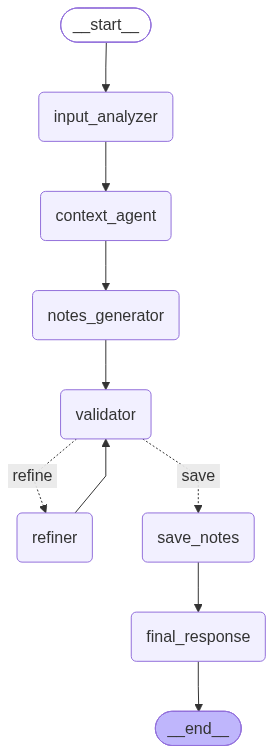

In [22]:
from IPython.display import Image, display

try:
    display(
        Image(
            app.get_graph().draw_mermaid_png()
        )
    )
except Exception as error:
    print("Graph visualization unavailable:", error)


# 🚀 Run the AI Notes Generator


In [23]:
USER_ID = "demo_user_001"
CONVERSATION_ID = "conversation_001"

user_query = "Create beginner-friendly notes about JavaScript closures with practical examples."

save_conversation_message(
    conversation_id=CONVERSATION_ID,
    user_id=USER_ID,
    role="user",
    content=user_query,
)

initial_state = {
    "messages": [
        HumanMessage(content=user_query)
    ],
    "user_id": USER_ID,
    "conversation_id": CONVERSATION_ID,
    "user_query": user_query,
    "topic": "",
    "source_context": "",
    "note_style": "structured study notes",
    "difficulty_level": "beginner",
    "generated_notes": None,
    "validation_result": None,
    "refinement_count": 0,
    "final_response": "",
    "metadata": {},
}

result = app.invoke(initial_state)

print(result["final_response"])


C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3331525712.py:30: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow(),
C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3331525712.py:34: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow()
C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3331525712.py:37: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow()



# JavaScript Closures – Beginner Study Notes

## Summary
Closures let a function remember variables from its creation context, enabling private data, stateful functions, and modular code. They’re created when an inner function references variables from an outer function, and they’re useful for counters, factories, event handlers, and encapsulation.

## Key Concepts

- closure
- lexical environment
- scope chain
- private data
- function factory
- module pattern

## Detailed Notes

- 1. **What is a closure?** In JavaScript, a closure is a function that remembers the variables from the place where it was created, even after that outer function has finished running.
- 2. **Why closures are useful?** They let you keep data private, create function factories, and maintain state across function calls without using global variables.
- 3. **How does it work?** When a function is defined, JavaScript creates a *lexical environment* that contains all the variables it can access. The function kee

C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3824794738.py:13: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow(),
C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3331525712.py:30: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow(),
C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3331525712.py:34: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow()
C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3331525712.py:37: DeprecationWarn

# 💬 Test Memory with a Follow-up Request

The second request can use MongoDB conversation memory.


In [24]:
follow_up_query = "Make the notes shorter and add two more real-world examples."

save_conversation_message(
    conversation_id=CONVERSATION_ID,
    user_id=USER_ID,
    role="user",
    content=follow_up_query,
)

follow_up_state = {
    "messages": [
        HumanMessage(content=follow_up_query)
    ],
    "user_id": USER_ID,
    "conversation_id": CONVERSATION_ID,
    "user_query": follow_up_query,
    "topic": "",
    "source_context": "",
    "note_style": "concise revision notes",
    "difficulty_level": "beginner",
    "generated_notes": None,
    "validation_result": None,
    "refinement_count": 0,
    "final_response": "",
    "metadata": {},
}

result = app.invoke(follow_up_state)

print(result["final_response"])


C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3331525712.py:30: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow(),
C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3331525712.py:34: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow()
C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3331525712.py:37: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow()



# JavaScript Closures – Beginner Revision Notes

## Summary
Closures let a function remember variables from its creation context, enabling private data, stateful functions, and modular code.

## Key Concepts

- closure
- lexical environment
- private data
- module pattern
- memoization

## Detailed Notes

- - A closure is a function that keeps a reference to the variables in its outer scope, even after that outer function has finished.
- - It lets you create private data, maintain state, and build reusable modules without globals.
- - Closures form automatically when an inner function accesses a variable from an outer function.

## Examples

- // 1. Counter
function createCounter(){let c=0;return()=>++c;}const counter=createCounter();console.log(counter(),counter());
- // 2. Greeting factory
function greetMaker(g){return n=>`${g}, ${n}!`;}
const sayHi=greetMaker('Hi');console.log(sayHi('Alice'));
- // 3. Loop with let
for(let i=1;i<=3;i++)setTimeout(()=>console.log(i),100*i);
- // 4. 

C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3824794738.py:13: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow(),
C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3331525712.py:30: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow(),
C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3331525712.py:34: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow()
C:\Users\sk335\AppData\Local\Temp\ipykernel_13932\3331525712.py:37: DeprecationWarn

# 🔎 Search Previously Generated Notes

MongoDB can be used to retrieve previous notes by topic.


In [25]:
def get_user_notes(user_id: str, limit: int = 10):
    return list(
        notes_collection.find(
            {"user_id": user_id},
            {"_id": 0},
        )
        .sort("created_at", -1)
        .limit(limit)
    )


saved_notes = get_user_notes(USER_ID)

for note in saved_notes:
    print(note["topic"])
    print(note["created_at"])
    print("-" * 50)


Make the notes shorter and add two more real-world examples.
2026-09-08 14:37:40.112000
--------------------------------------------------
Create beginner-friendly notes about JavaScript closures with practical examples.
2026-09-08 14:37:30.177000
--------------------------------------------------


# 🧠 Recommended Improvements

## 1. Add Document Upload + Agentic RAG

Future workflow:

```text
PDF / DOCX
    ↓
Document Loader
    ↓
Chunking
    ↓
Hugging Face Embeddings
    ↓
Vector Store
    ↓
Retriever Agent
    ↓
Notes Generator
```

Recommended:

- `PyPDFLoader`
- Hugging Face embeddings
- MongoDB Atlas Vector Search or another vector database

---

## 2. Add a Notes Type Router

Automatically detect:

- Study notes
- Revision notes
- Interview notes
- Flashcards
- Quiz questions
- MCQs
- Mind-map structure

Example:

```text
User Request
      ↓
Notes Type Router
      ↓
┌─────┬──────┬───────┐
Notes Quiz Flashcards
```

---

## 3. Add User Cross-Questioning

Before generating notes, the agent can ask useful questions:

- Beginner or advanced?
- Short or detailed?
- Notes for exam or interview?
- Include examples?

This prevents generating unnecessary content.

---

## 4. Add Streaming

Use:

```python
app.stream(...)
```

Then stream node progress to your FastAPI + React frontend.

---

## 5. Add Checkpointing

For production, add LangGraph persistence so workflows can resume.

Possible options:

- MongoDB-backed custom persistence
- PostgreSQL checkpointer
- Redis for short-term state

---

## 6. Add Notes Evaluation Metrics

Track:

- Generation latency
- Validation score
- Number of refinement loops
- Token usage
- User satisfaction

This is excellent for a portfolio project.

---

## 7. Best Production Architecture

```text
React Frontend
      ↓
FastAPI
      ↓
LangGraph Agent
      ↓
Groq
      │
      ├── MongoDB → Notes + Conversations
      │
      ├── Redis → Cache / Short-term state
      │
      └── Hugging Face → Embeddings
              ↓
        MongoDB Vector Search
```

## Portfolio Project Title

**ClassBuddy AI — Agentic Notes Generation System**

> A multi-agent AI notes generation system that uses LangGraph for orchestration, Groq for fast inference, MongoDB for persistent memory and notes storage, and Hugging Face embeddings for semantic retrieval. The system validates generated educational content and automatically refines low-quality responses through an agentic feedback loop.
